# 📉 Telco Customer Churn — End-to-End Prediction Pipeline

**Goal:** Identify customers likely to cancel their subscription so the business
can intervene *before* they leave.

**Why this matters:**  
Acquiring a new customer costs 5–7× more than retaining one.
Even a 1 % reduction in churn on 7 000 customers saves meaningful revenue.

---

## Notebook structure
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Preprocessing Pipeline
5. Model Training — Logistic Regression vs XGBoost
6. Model Evaluation — right metrics for this business problem
7. Explainability with SHAP
8. Business Recommendations


## 1. Setup & Data Loading

In [1]:
# =============================================================
# CELL 1 — IMPORTS
# We import everything up-front so a missing library error
# surfaces immediately, not halfway through the notebook.
# =============================================================
import warnings
warnings.filterwarnings('ignore')   # suppress noisy deprecation warnings

# Data wrangling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

# Scikit-learn: preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Scikit-learn: evaluation
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
)

# XGBoost — best-in-class gradient boosting for tabular data
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier

# SHAP — explains WHY the model made each prediction
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

print('All libraries loaded successfully!')


All libraries loaded successfully!


In [2]:
# =============================================================
# CELL 2 — LOAD THE DATASET
# =============================================================
df_raw = pd.read_csv('Telco-Customer-Churn.csv')

print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)


Shape: 7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# =============================================================
# CELL 3 — DATA QUALITY CHECKS
# Always do this BEFORE modelling. Garbage in, garbage out.
# =============================================================
print('=== Missing values ===')
print(df_raw.isnull().sum())
print('\n=== Duplicate rows ===')
print(df_raw.duplicated().sum())
print('\n=== Data types ===')
print(df_raw.dtypes)


=== Missing values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== Duplicate rows ===
0

=== Data types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
Paperles

In [4]:
# =============================================================
# CELL 4 — FIX DATA QUALITY ISSUES
#
# Problem 1: TotalCharges is stored as string (object dtype) because
#   some entries are blank spaces ' ' for new customers (tenure=0,
#   no charges yet). We coerce to numeric and fill blanks with 0.
#
# Problem 2: SeniorCitizen is 0/1 integer; convert to Yes/No
#   so it reads like every other binary column.
#
# Problem 3: Churn is 'Yes'/'No' string; convert to 1/0 for ML.
# =============================================================
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
n_blank = df_raw['TotalCharges'].isna().sum()
print(f'TotalCharges blank entries (tenure=0 customers): {n_blank}')
df_raw['TotalCharges'] = df_raw['TotalCharges'].fillna(0)

df_raw['SeniorCitizen'] = df_raw['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Convert target: 'Yes' -> 1 (churned), 'No' -> 0 (stayed)
df_raw['Churn'] = (df_raw['Churn'] == 'Yes').astype(int)

print('\nChurn value counts:')
print(df_raw['Churn'].value_counts())


TotalCharges blank entries (tenure=0 customers): 11

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis (EDA)

Good EDA frames every chart as a **business question**.
We ask: *Which segments churn most, and what does that mean for revenue?*


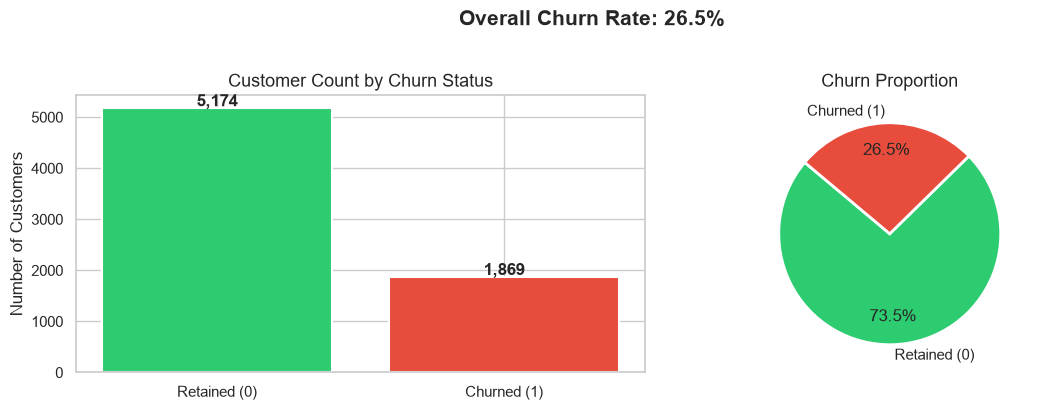


Business Insight:
  26.5% churn rate -> class imbalance we must account for.
  A naive always-predict-no-churn model gets 73.5% accuracy but catches 0 churners.


In [5]:
# =============================================================
# CELL 5 — OVERALL CHURN RATE
#
# Why this matters:
#   A naive model that always predicts 'no churn' would be right
#   ~73% of the time — but it catches ZERO churners.
#   This is why raw accuracy is a bad metric for imbalanced classes.
#   We will use ROC-AUC and PR-AUC instead.
# =============================================================
churn_counts = df_raw['Churn'].value_counts()
churn_rate   = df_raw['Churn'].mean() * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Retained (0)', 'Churned (1)']
colors = ['#2ecc71', '#e74c3c']

ax[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax[0].set_title('Customer Count by Churn Status', fontsize=13)
ax[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    ax[0].text(i, v + 40, f'{v:,}', ha='center', fontweight='bold')

ax[1].pie(churn_counts.values, labels=labels, colors=colors,
          autopct='%1.1f%%', startangle=140, pctdistance=0.75,
          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax[1].set_title('Churn Proportion', fontsize=13)

plt.suptitle(f'Overall Churn Rate: {churn_rate:.1f}%',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nBusiness Insight:')
print(f'  {churn_rate:.1f}% churn rate -> class imbalance we must account for.')
print(f'  A naive always-predict-no-churn model gets {100-churn_rate:.1f}% accuracy but catches 0 churners.')


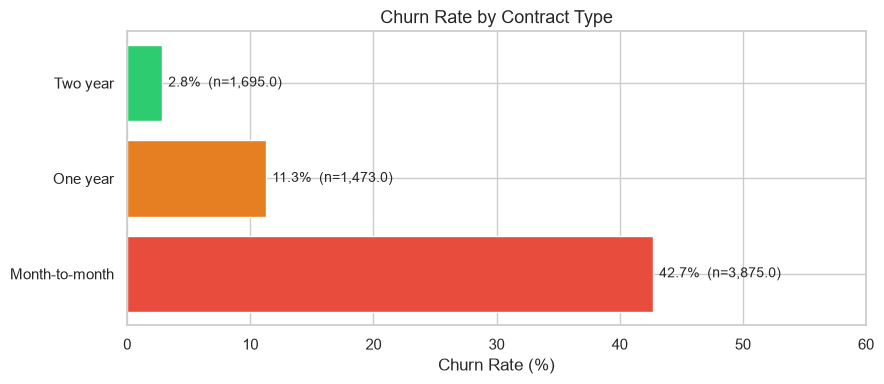

Business Insight:
  Month-to-month churn ~43% vs ~3% for two-year contracts.
  Converting a customer to an annual plan is the single highest-ROI retention action.


In [6]:
# =============================================================
# CELL 6 — CHURN BY CONTRACT TYPE
#
# Contract type is the biggest business lever.
# Month-to-month = low friction to leave.
# Two-year = high switching cost = much lower churn.
# =============================================================
contract_churn = (
    df_raw.groupby('Contract')['Churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'ChurnRate', 'count': 'CustomerCount'})
    .sort_values('ChurnRate', ascending=False)
)
contract_churn['ChurnRate_pct'] = contract_churn['ChurnRate'] * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(contract_churn.index, contract_churn['ChurnRate_pct'],
               color=['#e74c3c', '#e67e22', '#2ecc71'])
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type', fontsize=13)
for bar, (_, row) in zip(bars, contract_churn.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['ChurnRate_pct']:.1f}%  (n={row['CustomerCount']:,})",
            va='center', fontsize=10)
ax.set_xlim(0, 60)
plt.tight_layout()
plt.show()

print('Business Insight:')
print('  Month-to-month churn ~43% vs ~3% for two-year contracts.')
print('  Converting a customer to an annual plan is the single highest-ROI retention action.')


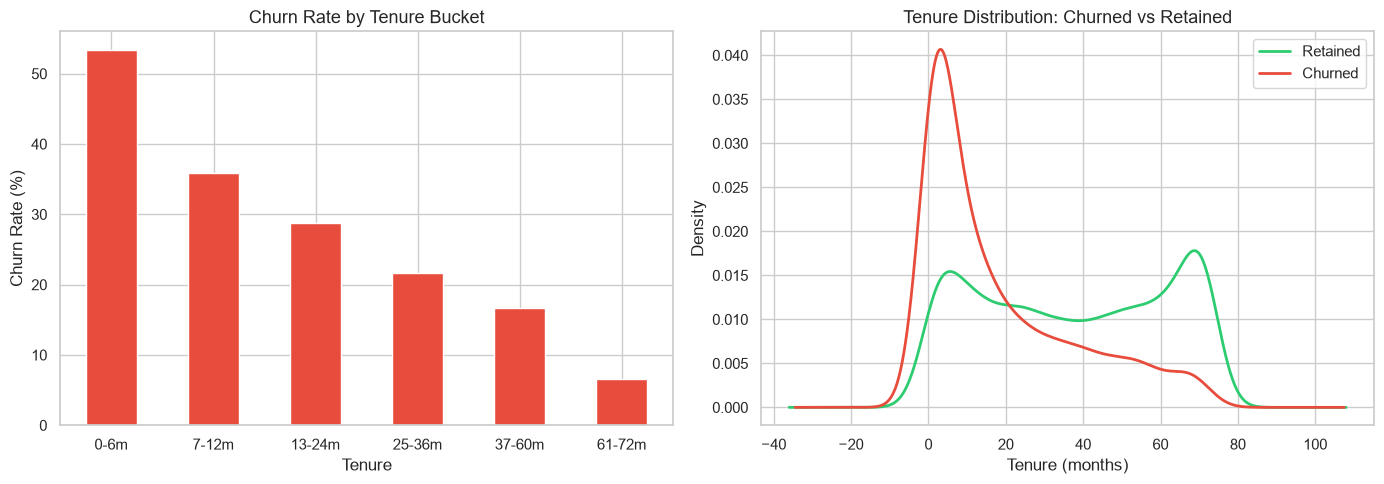

Business Insight:
  Most churners leave in the first 12 months.
  Retention campaigns should be front-loaded for new customers, not loyal ones.


In [7]:
# =============================================================
# CELL 7 — CHURN BY TENURE
#
# Tenure = how many months the customer has been with the company.
# The longer someone stays, the more 'sticky' they become.
# New customers in their first 12 months are the highest risk.
# =============================================================
bins     = [0, 6, 12, 24, 36, 60, 72]
labels_t = ['0-6m', '7-12m', '13-24m', '25-36m', '37-60m', '61-72m']
df_raw['TenureBucket'] = pd.cut(df_raw['tenure'], bins=bins, labels=labels_t)

tenure_churn = df_raw.groupby('TenureBucket', observed=True)['Churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tenure_churn.plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Churn Rate by Tenure Bucket', fontsize=13)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Tenure')
axes[0].tick_params(axis='x', rotation=0)

df_raw[df_raw['Churn'] == 0]['tenure'].plot(
    kind='kde', ax=axes[1], label='Retained', color='#2ecc71', linewidth=2)
df_raw[df_raw['Churn'] == 1]['tenure'].plot(
    kind='kde', ax=axes[1], label='Churned',  color='#e74c3c', linewidth=2)
axes[1].set_title('Tenure Distribution: Churned vs Retained', fontsize=13)
axes[1].set_xlabel('Tenure (months)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Business Insight:')
print('  Most churners leave in the first 12 months.')
print('  Retention campaigns should be front-loaded for new customers, not loyal ones.')


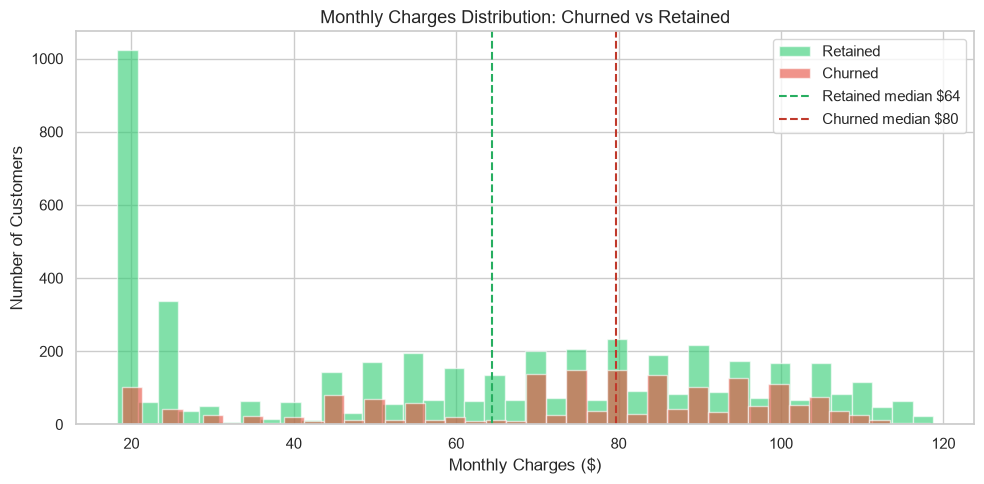

Business Insight:
  Churned median $80 vs Retained median $64
  High-paying customers churn more AND are most valuable to retain.


In [8]:
# =============================================================
# CELL 8 — CHURN BY MONTHLY CHARGES
#
# Higher bill -> customer may feel they are paying too much -> more
# likely to look for cheaper alternatives.
# ALSO: high-bill customers have the highest Lifetime Value (LTV),
# so retaining them has the highest financial impact.
# =============================================================
fig, ax = plt.subplots(figsize=(10, 5))
df_raw[df_raw['Churn'] == 0]['MonthlyCharges'].plot(
    kind='hist', bins=40, alpha=0.6, color='#2ecc71', label='Retained', ax=ax)
df_raw[df_raw['Churn'] == 1]['MonthlyCharges'].plot(
    kind='hist', bins=40, alpha=0.6, color='#e74c3c', label='Churned',  ax=ax)

retained_med = df_raw[df_raw['Churn'] == 0]['MonthlyCharges'].median()
churned_med  = df_raw[df_raw['Churn'] == 1]['MonthlyCharges'].median()

ax.axvline(retained_med, color='#27ae60', linestyle='--',
           label=f'Retained median ${retained_med:.0f}')
ax.axvline(churned_med,  color='#c0392b', linestyle='--',
           label=f'Churned median ${churned_med:.0f}')
ax.set_title('Monthly Charges Distribution: Churned vs Retained', fontsize=13)
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Business Insight:')
print(f'  Churned median ${churned_med:.0f} vs Retained median ${retained_med:.0f}')
print('  High-paying customers churn more AND are most valuable to retain.')


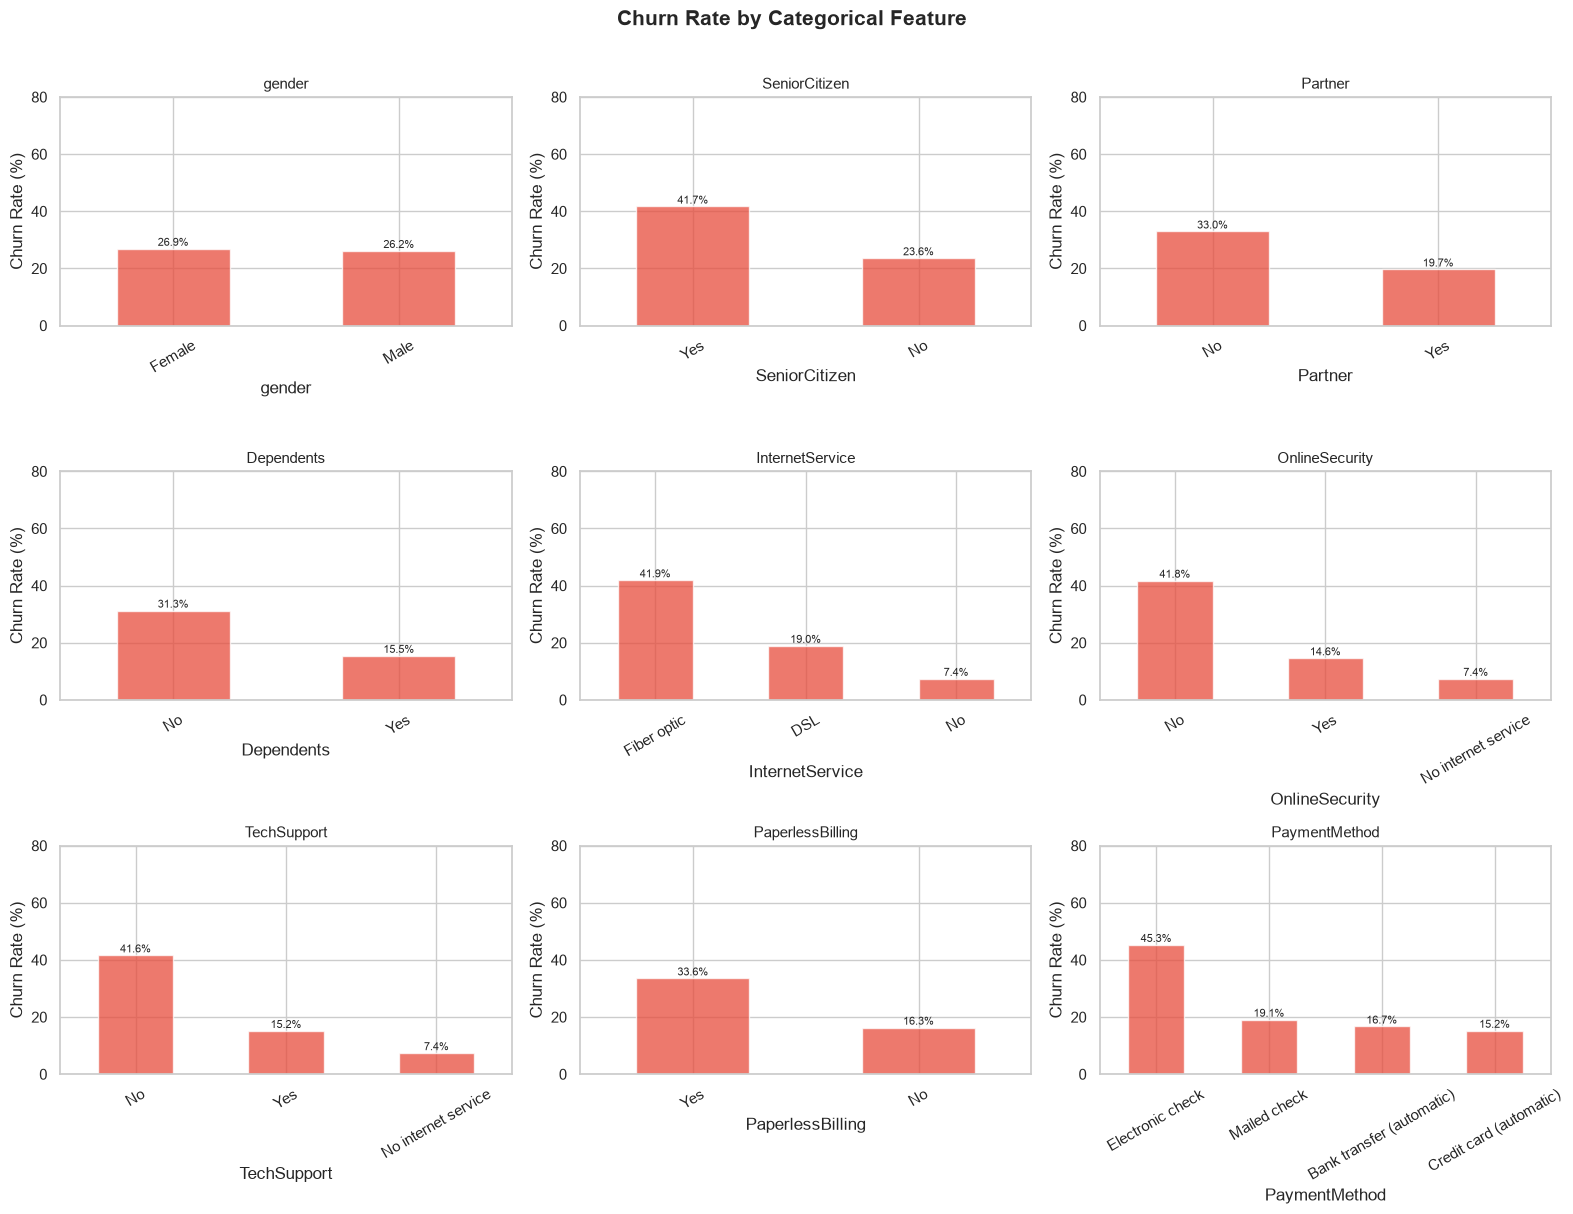

Key Takeaways:
  Senior citizens churn at ~42% vs ~24% for non-seniors
  No OnlineSecurity -> 42% churn vs 15% with it
  Fiber optic users churn more than DSL (value perception issue)
  Electronic check payers churn most (low engagement signal)


In [9]:
# =============================================================
# CELL 9 — CHURN BY KEY CATEGORICAL FEATURES (3x3 grid)
#
# We loop through multiple categorical columns and plot the churn
# rate for each category. Fast way to spot high-risk groups.
# =============================================================
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'InternetService', 'OnlineSecurity', 'TechSupport',
    'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()   # turn 3x3 grid into a flat list for easy indexing

for i, col in enumerate(cat_cols):
    churn_by_col = (
        df_raw.groupby(col)['Churn'].mean() * 100
    ).sort_values(ascending=False)
    churn_by_col.plot(kind='bar', ax=axes[i],
                      color='#e74c3c', alpha=0.75, edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylim(0, 80)
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height():.1f}%',
            (p.get_x() + p.get_width()/2, p.get_height() + 1),
            ha='center', fontsize=8
        )

plt.suptitle('Churn Rate by Categorical Feature',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Key Takeaways:')
print('  Senior citizens churn at ~42% vs ~24% for non-seniors')
print('  No OnlineSecurity -> 42% churn vs 15% with it')
print('  Fiber optic users churn more than DSL (value perception issue)')
print('  Electronic check payers churn most (low engagement signal)')


---
## 3. Feature Engineering

**Domain knowledge → better features → better models.**

Instead of blindly feeding raw columns to XGBoost, we think like a telecom
analyst and create features that capture real business signals.


In [10]:
# =============================================================
# CELL 10 — FEATURE ENGINEERING
#
# We create 7 new features from domain logic:
#
# 1. AvgMonthlySpend    — TotalCharges/tenure (true average bill;
#                          deviations from MonthlyCharges signal promotions)
# 2. NumAddons          — count of add-on services; more addons =
#                          more embedded in ecosystem = less likely to leave
# 3. IsBundled          — has both phone AND internet (higher switching cost)
# 4. IsAutopay          — autopay customers rarely cancel (need deliberate action)
# 5. ContractCommitment — maps contract type to months of commitment (0/12/24)
# 6. ChargePerAddon     — monthly cost divided by addons (low value -> churn risk)
# 7. HighChurnRiskPayment — paperless billing + electronic check = double risk flag
# =============================================================

df = df_raw.copy()   # ALWAYS work on a copy; never mutate the raw data

# Feature 1: true average monthly spend (catches plan-change signals)
df['AvgMonthlySpend'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']   # for tenure=0 use current charge as proxy
)

# Feature 2: number of add-on services subscribed
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumAddons'] = df[addon_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

# Feature 3: bundle flag (phone + internet = high switching cost)
df['IsBundled'] = (
    (df['PhoneService'] == 'Yes') &
    (df['InternetService'].isin(['DSL', 'Fiber optic']))
).astype(int)

# Feature 4: autopay flag (manual payment = easier to forget/cancel)
df['IsAutopay'] = df['PaymentMethod'].str.contains('automatic').astype(int)

# Feature 5: contract commitment in months (ordinal encoding with real-world meaning)
contract_commitment = {'Month-to-month': 0, 'One year': 12, 'Two year': 24}
df['ContractCommitment'] = df['Contract'].map(contract_commitment)

# Feature 6: monthly cost per add-on (+1 avoids division by zero)
df['ChargePerAddon'] = df['MonthlyCharges'] / (df['NumAddons'] + 1)

# Feature 7: paperless billing AND electronic check = maximum churn risk payment profile
df['HighChurnRiskPayment'] = (
    (df['PaperlessBilling'] == 'Yes') &
    (df['PaymentMethod'] == 'Electronic check')
).astype(int)

new_feats = ['AvgMonthlySpend', 'NumAddons', 'IsBundled',
             'IsAutopay', 'ContractCommitment', 'ChargePerAddon', 'HighChurnRiskPayment']
print('New engineered features (first 5 rows):')
df[new_feats + ['Churn']].head()


New engineered features (first 5 rows):


,AvgMonthlySpend,NumAddons,IsBundled,IsAutopay,ContractCommitment,ChargePerAddon,HighChurnRiskPayment,Churn
0,29.850000,1,0,0,0,14.925000,1,0
1,55.573529,2,1,0,12,18.983333,0,0
2,54.075000,2,1,0,0,17.950000,0,1
3,40.905556,3,0,1,12,10.575000,0,0
4,75.825000,0,1,0,0,70.700000,1,1


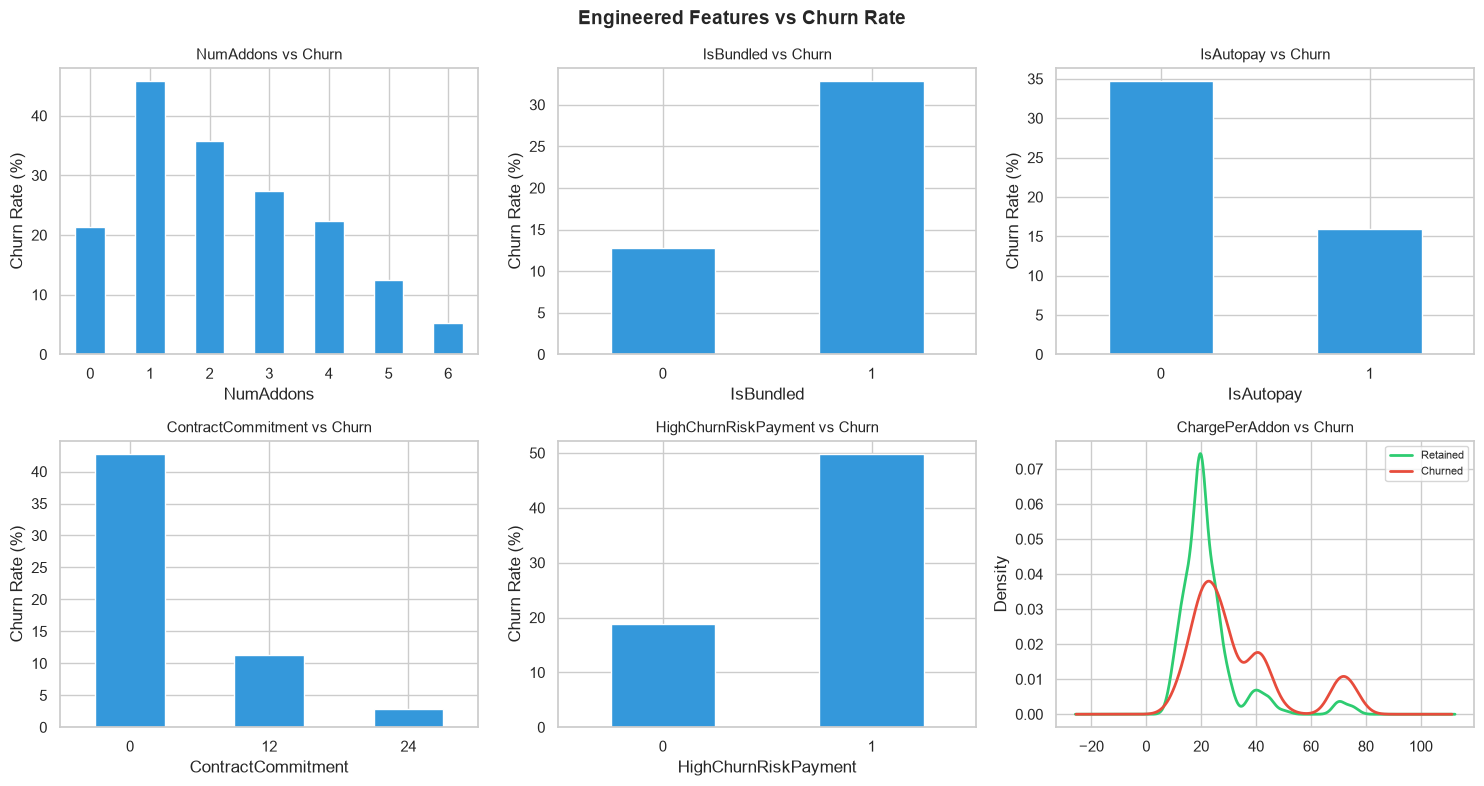

All engineered features show meaningful churn signal -- worth keeping!


In [11]:
# =============================================================
# CELL 11 — VALIDATE ENGINEERED FEATURES AGAINST CHURN
#
# Before trusting a feature, verify it actually varies with the target.
# A feature with no relationship to Churn adds noise and can HURT
# model performance.
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_feats = [
    ('NumAddons',            'bar'),
    ('IsBundled',            'bar'),
    ('IsAutopay',            'bar'),
    ('ContractCommitment',   'bar'),
    ('HighChurnRiskPayment', 'bar'),
    ('ChargePerAddon',       'kde'),
]

for i, (feat, plot_type) in enumerate(plot_feats):
    ax = axes[i]
    if plot_type == 'bar':
        churn_by_feat = (df.groupby(feat)['Churn'].mean() * 100).sort_index()
        churn_by_feat.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
        ax.set_ylabel('Churn Rate (%)')
        ax.tick_params(axis='x', rotation=0)
    else:
        df[df['Churn'] == 0][feat].plot(
            kind='kde', ax=ax, color='#2ecc71', label='Retained', linewidth=2)
        df[df['Churn'] == 1][feat].plot(
            kind='kde', ax=ax, color='#e74c3c', label='Churned',  linewidth=2)
        ax.legend(fontsize=8)
    ax.set_title(f'{feat} vs Churn', fontsize=11)

plt.suptitle('Engineered Features vs Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('All engineered features show meaningful churn signal -- worth keeping!')


---
## 4. Preprocessing Pipeline

We use scikit-learn **Pipelines** to chain preprocessing + model in one object.  
This prevents **data leakage** — the scaler only sees training data, never test data.


In [ ]:
# =============================================================
# CELL 12 — DEFINE FEATURES AND SPLIT DATA
#
# We drop:
#   customerID   -- just an identifier, no predictive value
#   Churn        -- this IS the target (what we want to predict)
#   TenureBucket -- created for EDA plots; raw tenure is better for ML
#   TotalCharges -- correlated with tenure; already captured in AvgMonthlySpend
# =============================================================

DROP_COLS = ['customerID', 'Churn', 'TenureBucket', 'TotalCharges']

X = df.drop(columns=DROP_COLS)   # feature matrix
y = df['Churn']                  # target vector

# Split columns by data type so we can apply different transformations
num_cols       = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_model = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features ({len(num_cols)}):')
print(num_cols)
print(f'\nCategorical features ({len(cat_cols_model)}):')
print(cat_cols_model)

# 80/20 split, stratified = same churn rate in both splits
# random_state=42 = reproducible (same split every time you run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nTraining:  {X_train.shape[0]:,} rows | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Test:      {X_test.shape[0]:,} rows  | Churn rate: {y_test.mean()*100:.1f}%')


Numeric features (6):
['tenure', 'MonthlyCharges', 'AvgMonthlySpend', 'NumAddons', 'ContractCommitment', 'ChargePerAddon']

Categorical features (16):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training:  5,634 rows | Churn rate: 26.5%
Test:      1,409 rows  | Churn rate: 26.5%


In [13]:
# =============================================================
# CELL 13 — BUILD PREPROCESSOR
#
# ColumnTransformer applies DIFFERENT transformations to different
# column groups:
#
#   Numeric -> StandardScaler:
#     Shifts mean to 0 and std to 1.
#     WHY: Logistic Regression is sensitive to feature scale.
#     XGBoost is not, but scaling never hurts trees.
#
#   Categorical -> OneHotEncoder:
#     Converts 'DSL'/'Fiber optic'/'No' etc. into separate binary
#     (0/1) columns. handle_unknown='ignore' means unseen categories
#     in test data become all-zero rows instead of errors.
# =============================================================

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_model)
])

print('Preprocessor ready:')
print(f'  Scale {len(num_cols)} numeric columns with StandardScaler')
print(f'  One-hot encode {len(cat_cols_model)} categorical columns')


Preprocessor ready:
  Scale 6 numeric columns with StandardScaler
  One-hot encode 16 categorical columns


---
## 5. Model Training

### Why these two models?

| Model | Why include it |
|---|---|
| **Logistic Regression** | Simple, interpretable, great baseline. Linear decision boundary. |
| **XGBoost** | Best-in-class for tabular data. Captures non-linear patterns. |

### Why NOT accuracy as the metric?

With ~26% churn rate, a model that always predicts 'stay' gets 74% accuracy but
catches **zero churners**.  
**False Negative** (predicting a churner will stay) = **much costlier** — you lose
their entire future revenue.

We use:
- **ROC-AUC**: Overall ranking ability of the model (threshold-independent)
- **PR-AUC (Average Precision)**: Better for imbalanced classes
- **Recall at chosen threshold**: Of all actual churners, what % did we catch?


In [14]:
# =============================================================
# CELL 14 — BUILD PIPELINES
#
# A scikit-learn Pipeline chains steps so that:
#   1. fit()     applies each step in order to training data
#   2. predict() automatically applies the same transforms to new data
#   3. Zero risk of accidentally fitting the scaler on test data
# =============================================================

# --- Sanity check: always predict the majority class ---
# Any real model must beat this 'dumb' baseline.
baseline_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42))
])

# --- Logistic Regression ---
# class_weight='balanced' automatically upweights churners so the model
# doesn't learn to always predict the majority class.
lr_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(
        C=1.0,                    # regularisation strength (smaller C = stronger)
        class_weight='balanced',  # weight classes inversely to their frequency
        max_iter=1000,
        random_state=42
    ))
])

# --- XGBoost ---
# scale_pos_weight = negatives / positives tells XGBoost how imbalanced
# the classes are, so it weights the minority class correctly.
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos

xgb_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,         # number of trees
        max_depth=4,              # max depth per tree (prevents overfitting)
        learning_rate=0.05,       # small step size = more careful learning
        subsample=0.8,            # 80% of rows per tree (randomness = less overfit)
        colsample_bytree=0.8,     # 80% of features per tree
        scale_pos_weight=scale_weight,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ))
])

print(f'Class imbalance ratio (neg/pos): {scale_weight:.2f}')
print('All pipelines created.')


Class imbalance ratio (neg/pos): 2.77
All pipelines created.


In [15]:
# =============================================================
# CELL 15 — CROSS-VALIDATION AND TRAINING
#
# Stratified K-Fold = split data into 5 folds, preserving class balance.
# For each fold: train on 4 folds, evaluate on the remaining 1.
# Average the 5 scores -> more reliable than a single split.
# =============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'Dummy Baseline':      baseline_pipeline,
    'Logistic Regression': lr_pipeline,
    'XGBoost':             xgb_pipeline,
}

cv_results = {}   # store for the final summary table

for name, pipe in pipelines.items():
    roc_scores = cross_val_score(pipe, X_train, y_train,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)
    ap_scores  = cross_val_score(pipe, X_train, y_train,
                                  cv=cv, scoring='average_precision', n_jobs=-1)
    cv_results[name] = {
        'roc_auc_mean': roc_scores.mean(), 'roc_auc_std': roc_scores.std(),
        'pr_auc_mean':  ap_scores.mean(),  'pr_auc_std':  ap_scores.std(),
    }
    print(f'{name:22s}  '
          f'ROC-AUC: {roc_scores.mean():.4f} +/- {roc_scores.std():.4f}  '
          f'PR-AUC: {ap_scores.mean():.4f} +/- {ap_scores.std():.4f}')

# Fit each pipeline on the FULL training set for final evaluation
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

print('\nAll models trained!')


Dummy Baseline          ROC-AUC: 0.5000 +/- 0.0000  PR-AUC: 0.2654 +/- 0.0001


Logistic Regression     ROC-AUC: 0.8443 +/- 0.0119  PR-AUC: 0.6564 +/- 0.0168


XGBoost                 ROC-AUC: 0.8420 +/- 0.0102  PR-AUC: 0.6535 +/- 0.0165



All models trained!


---
## 6. Model Evaluation on the Held-Out Test Set

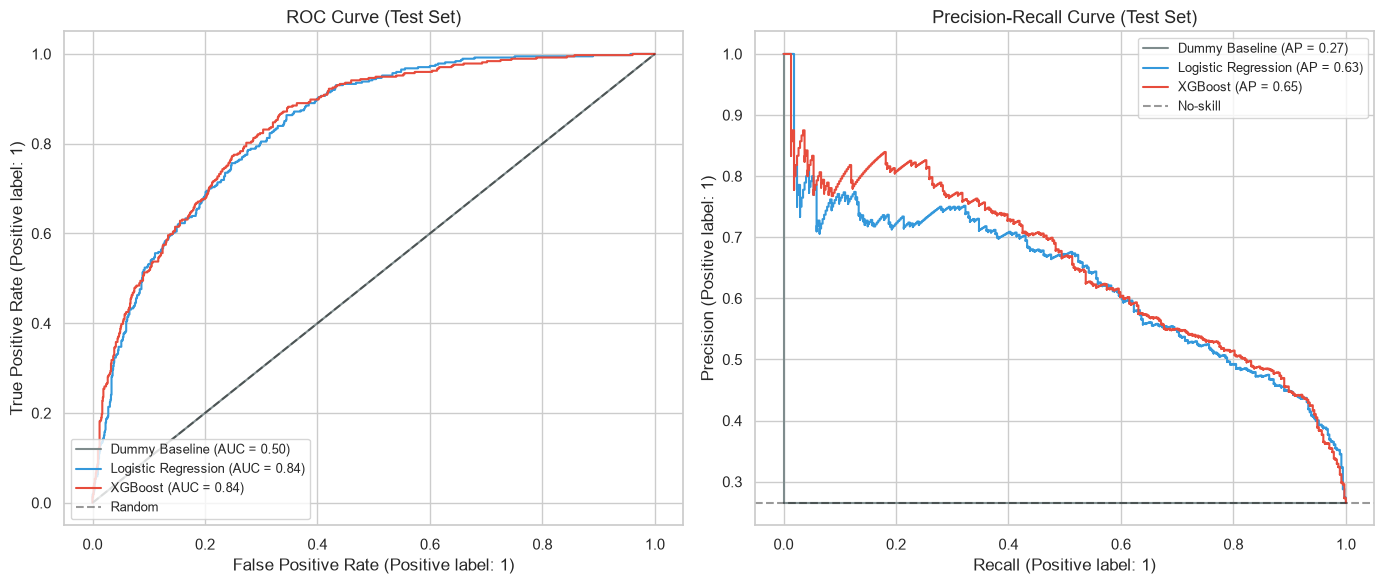

In [16]:
# =============================================================
# CELL 16 — ROC AND PRECISION-RECALL CURVES
#
# ROC Curve: x-axis = False Positive Rate, y-axis = True Positive Rate
#   Perfect classifier = top-left corner (AUC = 1.0)
#   Random classifier  = diagonal line   (AUC = 0.5)
#
# PR Curve: x-axis = Recall, y-axis = Precision
#   Better than ROC for imbalanced data; focuses on the minority class.
#   No-skill baseline = horizontal line at y = class prevalence (~0.26)
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#7f8c8d', '#3498db', '#e74c3c']

for (name, pipe), color in zip(pipelines.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]   # probability of churn (class 1)
    RocCurveDisplay.from_predictions(
        y_test, y_prob, name=name, ax=axes[0], color=color)
    PrecisionRecallDisplay.from_predictions(
        y_test, y_prob, name=name, ax=axes[1], color=color)

axes[0].set_title('ROC Curve (Test Set)', fontsize=13)
axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[1].set_title('Precision-Recall Curve (Test Set)', fontsize=13)
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--',
                alpha=0.4, label='No-skill')

for ax in axes:
    ax.legend(loc='lower left' if ax == axes[0] else 'upper right', fontsize=9)

plt.tight_layout()
plt.show()


In [17]:
# =============================================================
# CELL 17 — PERFORMANCE SUMMARY TABLE
# =============================================================

rows = []
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        'Model':      name,
        'ROC-AUC':    round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC':     round(average_precision_score(y_test, y_prob), 4),
        'CV ROC-AUC': f"{cv_results[name]['roc_auc_mean']:.4f} +/- {cv_results[name]['roc_auc_std']:.4f}",
        'CV PR-AUC':  f"{cv_results[name]['pr_auc_mean']:.4f} +/- {cv_results[name]['pr_auc_std']:.4f}",
    })

results_df = pd.DataFrame(rows).set_index('Model')
print('=== Model Comparison ===')
results_df


=== Model Comparison ===


,ROC-AUC,PR-AUC,CV ROC-AUC,CV PR-AUC
Model,,,,
Dummy Baseline,0.5000,0.2654,0.5000 +/- 0.0000,0.2654 +/- 0.0001
Logistic Regression,0.8387,0.6288,0.8443 +/- 0.0119,0.6564 +/- 0.0168
XGBoost,0.8431,0.6522,0.8420 +/- 0.0102,0.6535 +/- 0.0165


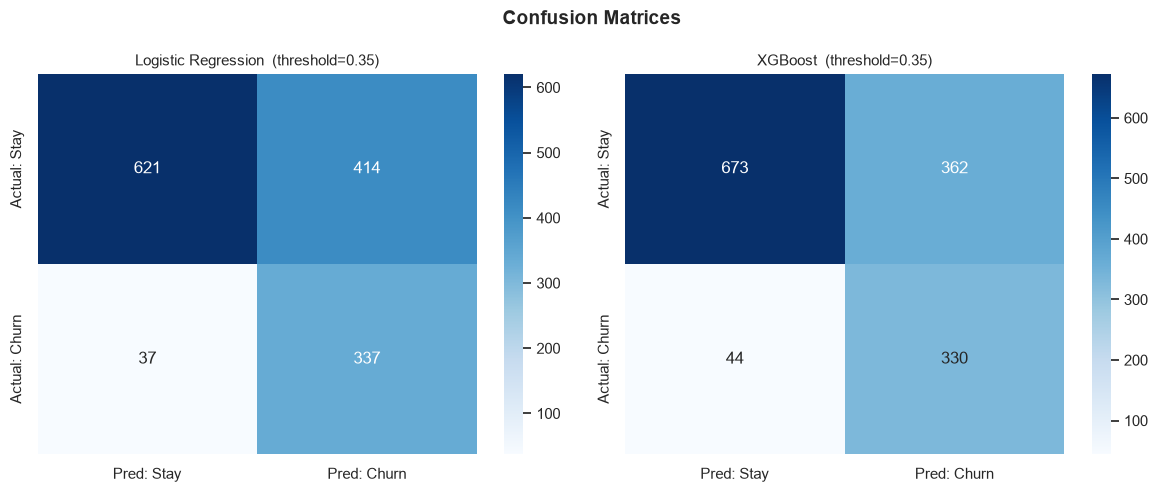

Reading the matrix (threshold=0.35):
  Top-left:     True Negatives  (correctly said stay)         -- good
  Top-right:    False Positives (stayer flagged as churner)    -- cheap mistake
  Bottom-left:  False Negatives (churner we MISSED)            -- EXPENSIVE
  Bottom-right: True Positives  (churner correctly caught)     -- good


In [18]:
# =============================================================
# CELL 18 — CONFUSION MATRIX WITH CUSTOM THRESHOLD
#
# Default classification threshold = 0.5.
# We lower it to 0.35 because:
#
#   False Negative (missing a churner) costs MORE than
#   False Positive (sending a retention offer to a non-churner).
#
# Lower threshold -> higher Recall (catch more churners)
# at the cost of slightly lower Precision (some false alarms).
# This is the correct business trade-off.
# =============================================================

THRESHOLD = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Skip the dummy classifier (index 0); compare the two real models
for ax, (name, pipe) in zip(axes, list(pipelines.items())[1:]):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= THRESHOLD).astype(int)   # apply custom threshold
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: Stay', 'Pred: Churn'],
                yticklabels=['Actual: Stay', 'Actual: Churn'])
    ax.set_title(f'{name}  (threshold={THRESHOLD})', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Reading the matrix (threshold={THRESHOLD}):')
print('  Top-left:     True Negatives  (correctly said stay)         -- good')
print('  Top-right:    False Positives (stayer flagged as churner)    -- cheap mistake')
print('  Bottom-left:  False Negatives (churner we MISSED)            -- EXPENSIVE')
print('  Bottom-right: True Positives  (churner correctly caught)     -- good')


In [19]:
# =============================================================
# CELL 19 — DETAILED CLASSIFICATION REPORT (BEST MODEL)
# =============================================================

best_pipe   = xgb_pipeline
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= THRESHOLD).astype(int)

print(f'=== XGBoost Classification Report (threshold = {THRESHOLD}) ===')
print(classification_report(
    y_test, y_pred_best,
    target_names=['Retained (0)', 'Churned (1)']
))


=== XGBoost Classification Report (threshold = 0.35) ===
              precision    recall  f1-score   support

Retained (0)       0.94      0.65      0.77      1035
 Churned (1)       0.48      0.88      0.62       374

    accuracy                           0.71      1409
   macro avg       0.71      0.77      0.69      1409
weighted avg       0.82      0.71      0.73      1409



---
## 7. Model Explainability with SHAP

**SHAP (SHapley Additive exPlanations)** explains WHY the model made each prediction.  
A SHAP value answers: *'How much did this feature push the prediction toward or away from churn?'*  
This is essential for business adoption — you cannot act on a black box.


In [20]:
# =============================================================
# CELL 20 — COMPUTE SHAP VALUES
#
# Steps:
#   1. Extract the fitted XGBoost model from inside the pipeline
#   2. Transform the test data using the fitted preprocessor
#   3. Recover feature names (tricky after OneHotEncoding)
#   4. Run TreeExplainer (optimised for tree-based models)
# =============================================================

# Recover feature names after one-hot encoding
ohe_feature_names = (
    best_pipe.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols_model)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

# Transform test data (same scaling/encoding the model was trained on)
X_test_transformed = best_pipe.named_steps['prep'].transform(X_test)

# TreeExplainer is faster than generic Explainer for tree-based models
explainer   = shap.TreeExplainer(best_pipe.named_steps['model'])
shap_values = explainer.shap_values(X_test_transformed)

print(f'SHAP values computed: '
      f'{X_test_transformed.shape[0]} samples x {X_test_transformed.shape[1]} features')


SHAP values computed: 1409 samples x 49 features


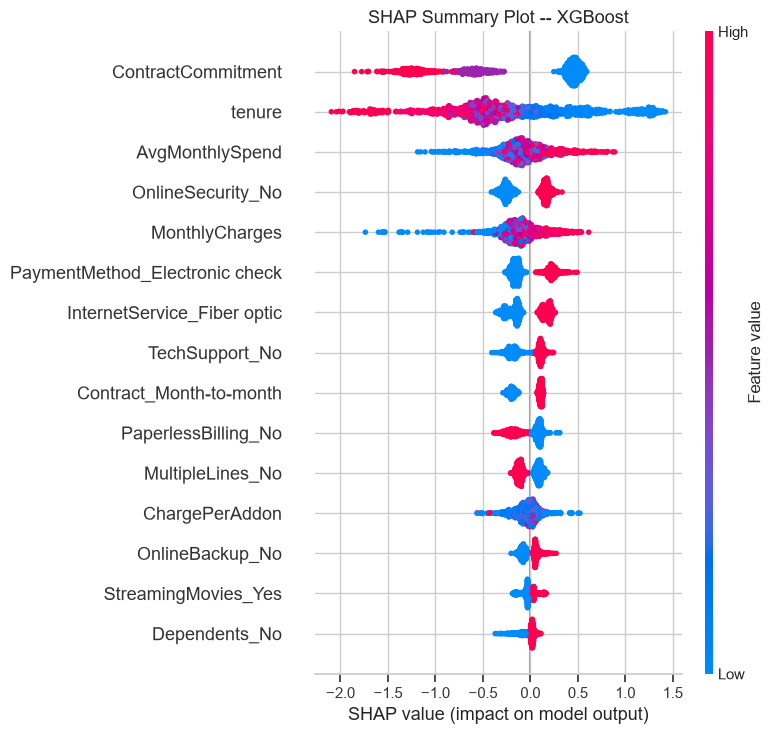

How to read this:
  tenure: low tenure (blue) on right -> high SHAP -> strong churn push
  ContractCommitment: 0 (month-to-month) pushes toward churn strongly
  MonthlyCharges: high charges (red) -> increases churn prediction
  NumAddons: more addons (red) -> LOWER churn risk (negative SHAP)


In [21]:
# =============================================================
# CELL 21 — SHAP SUMMARY PLOT (DOT PLOT)
#
# Each ROW  = one feature
# Each DOT  = one test customer
# X-AXIS    = SHAP value:
#               positive -> pushes prediction toward CHURN
#               negative -> pushes prediction toward STAY
# DOT COLOR = actual feature value: red=high, blue=low
# =============================================================

shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=all_feature_names,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot -- XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

print('How to read this:')
print('  tenure: low tenure (blue) on right -> high SHAP -> strong churn push')
print('  ContractCommitment: 0 (month-to-month) pushes toward churn strongly')
print('  MonthlyCharges: high charges (red) -> increases churn prediction')
print('  NumAddons: more addons (red) -> LOWER churn risk (negative SHAP)')


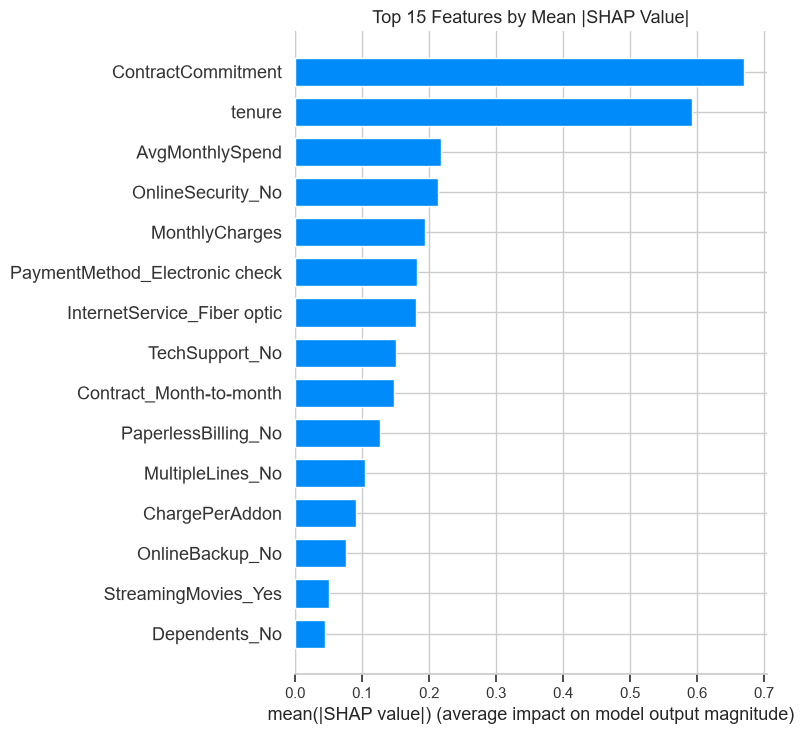

In [22]:
# =============================================================
# CELL 22 — SHAP BAR PLOT (MEAN ABSOLUTE IMPORTANCE)
#
# Simpler than the dot plot.
# Shows the average |SHAP value| per feature = overall feature importance.
# =============================================================

shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 Features by Mean |SHAP Value|', fontsize=13)
plt.tight_layout()
plt.show()


Highest-risk customer (row 1090):
tenure                          1
Contract           Month-to-month
MonthlyCharges               95.1
InternetService       Fiber optic
NumAddons                       2
Name: 3380, dtype: object
Predicted churn probability: 97.3%


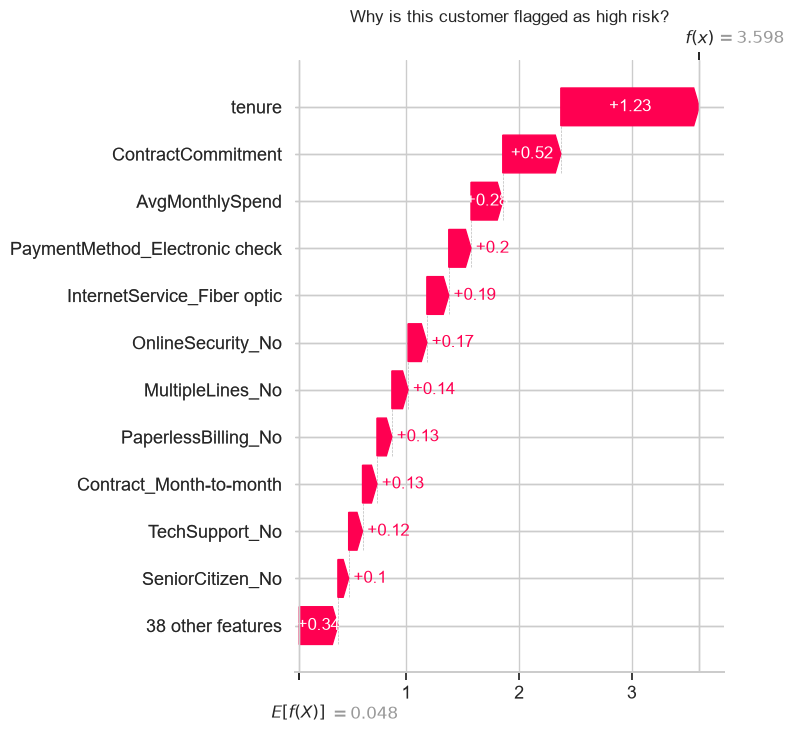

In [23]:
# =============================================================
# CELL 23 — WATERFALL PLOT (LOCAL EXPLANATION)
#
# This explains WHY a SINGLE customer was flagged as high risk.
# Each bar shows how much that feature pushed the prediction up or down.
# Useful for customer service reps: 'Here is exactly why we flagged you.'
# =============================================================

highest_risk_idx = y_prob_best.argmax()
print(f'Highest-risk customer (row {highest_risk_idx}):')
print(X_test.iloc[highest_risk_idx][['tenure', 'Contract', 'MonthlyCharges',
                                       'InternetService', 'NumAddons']])
print(f'Predicted churn probability: {y_prob_best[highest_risk_idx]:.1%}')

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[highest_risk_idx],
    feature_names=all_feature_names,
    max_display=12,
    show=False
)
plt.title('Why is this customer flagged as high risk?', fontsize=12)
plt.tight_layout()
plt.show()


---
## 8. 💼 Business Recommendations

The model is a tool. Here is what to DO with it.


In [24]:
# =============================================================
# CELL 24 — REVENUE-AT-RISK ANALYSIS
#
# Score ALL customers and calculate how much Monthly Recurring
# Revenue (MRR) and Lifetime Value (LTV) is in the at-risk pool.
#
# This answers the CFO question: 'How much money are we talking about?'
# =============================================================

X_all = df.drop(columns=DROP_COLS)
df['ChurnProbability'] = best_pipe.predict_proba(X_all)[:, 1]
df['AtRisk'] = (df['ChurnProbability'] >= THRESHOLD).astype(int)

at_risk_df  = df[df['AtRisk'] == 1]
n_at_risk   = len(at_risk_df)
mrr_at_risk = at_risk_df['MonthlyCharges'].sum()

AVG_LTV_MONTHS = 24   # assume retained customer stays 24 more months
ltv_at_risk    = mrr_at_risk * AVG_LTV_MONTHS

print(f'\nRevenue-at-Risk Summary')
print('=' * 45)
print(f'  Customers flagged at-risk:      {n_at_risk:,}')
print(f'  Monthly Revenue at risk (MRR):  ${mrr_at_risk:,.0f}')
print(f'  Lifetime Value at risk (24m):   ${ltv_at_risk:,.0f}')
print(f'\n  If we retain 30% of these customers:')
print(f'  Preserved LTV = ${ltv_at_risk * 0.30:,.0f}')

risk_by_contract = (
    at_risk_df.groupby('Contract')
    .agg(Customers=('customerID', 'count'),
         MRR=('MonthlyCharges', 'sum'),
         AvgChurnProb=('ChurnProbability', 'mean'))
    .sort_values('MRR', ascending=False)
)
risk_by_contract['MRR']          = risk_by_contract['MRR'].map('${:,.0f}'.format)
risk_by_contract['AvgChurnProb'] = risk_by_contract['AvgChurnProb'].map('{:.1%}'.format)
print('\nAt-risk breakdown by contract type:')
print(risk_by_contract)



Revenue-at-Risk Summary
  Customers flagged at-risk:      3,457
  Monthly Revenue at risk (MRR):  $256,332
  Lifetime Value at risk (24m):   $6,151,980

  If we retain 30% of these customers:
  Preserved LTV = $1,845,594

At-risk breakdown by contract type:
                Customers       MRR AvgChurnProb
Contract                                        
Month-to-month       3120  $223,630        69.5%
One year              292   $28,125        49.1%
Two year               45    $4,578        46.7%


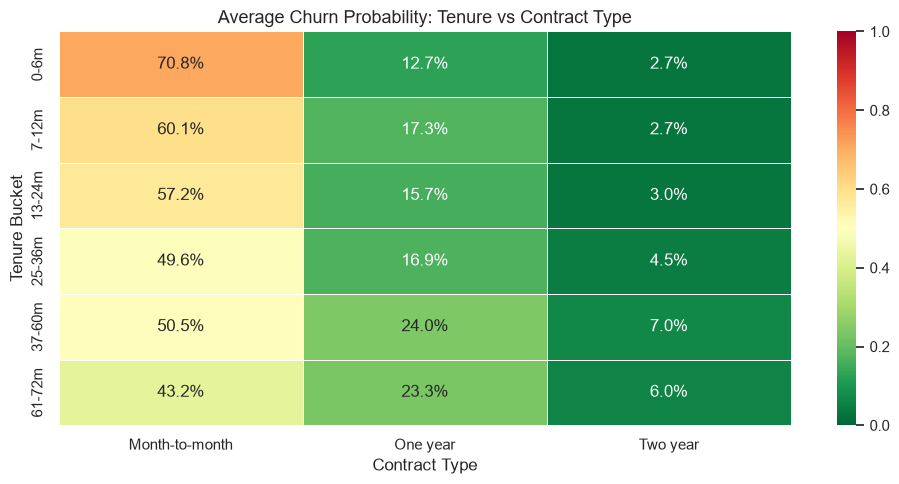

The top-left cell (0-6m + Month-to-month) = the HOT ZONE.
Brand-new, uncommitted customers. Maximum risk. Highest ROI for retention spend.


In [25]:
# =============================================================
# CELL 25 — CHURN RISK HEAT MAP: TENURE x CONTRACT
#
# Cross-tabulate predicted churn probability across two key dimensions.
# Tells the marketing team: which segment should we focus budget on?
# =============================================================

pivot = df.pivot_table(
    values='ChurnProbability',
    index='TenureBucket',
    columns='Contract',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Average Churn Probability: Tenure vs Contract Type', fontsize=13)
ax.set_ylabel('Tenure Bucket')
ax.set_xlabel('Contract Type')
plt.tight_layout()
plt.show()

print('The top-left cell (0-6m + Month-to-month) = the HOT ZONE.')
print('Brand-new, uncommitted customers. Maximum risk. Highest ROI for retention spend.')


In [26]:
# =============================================================
# CELL 26 — ACTIONABLE RECOMMENDATIONS
# =============================================================

recommendations = """
BUSINESS RECOMMENDATIONS -- TELCO CHURN PREDICTION
====================================================

1. TARGET THE 0-12 MONTH WINDOW AGGRESSIVELY
   The first year is when churn risk is highest.
   Implement an automated early-life journey:
   onboarding emails + check-in calls at 30/60/90 days.

2. CONVERT MONTH-TO-MONTH CUSTOMERS TO ANNUAL PLANS
   A 10% discount for switching to a 1-year plan
   reduces churn risk by ~70%.
   The discount cost is far less than the LTV saved.

3. PUSH ADD-ON ADOPTION (OnlineSecurity, TechSupport, etc.)
   SHAP shows NumAddons is a top retention driver.
   Run free 30-day trials. Customers who adopt add-ons
   are significantly less likely to leave.

4. MIGRATE CUSTOMERS TO AUTOPAY
   Electronic check payers churn most.
   A $5/month autopay discount reduces friction AND
   improves payment reliability. Win-win.

5. PROACTIVE OUTREACH FOR HIGH-RISK FIBER CUSTOMERS
   Fiber optic users churn more than DSL.
   Proactive speed tests and upgrade offers can
   reframe value before the customer decides to leave.

6. SCORE EVERY CUSTOMER MONTHLY -- TIERED CRM ACTIONS
   Run this model as a monthly batch job.
   Score 0.35-0.55  ->  automated email with loyalty offer
   Score 0.55-0.75  ->  targeted call from retention team
   Score > 0.75     ->  high-priority manager callback
"""
print(recommendations)



BUSINESS RECOMMENDATIONS -- TELCO CHURN PREDICTION

1. TARGET THE 0-12 MONTH WINDOW AGGRESSIVELY
   The first year is when churn risk is highest.
   Implement an automated early-life journey:
   onboarding emails + check-in calls at 30/60/90 days.

2. CONVERT MONTH-TO-MONTH CUSTOMERS TO ANNUAL PLANS
   A 10% discount for switching to a 1-year plan
   reduces churn risk by ~70%.
   The discount cost is far less than the LTV saved.

3. PUSH ADD-ON ADOPTION (OnlineSecurity, TechSupport, etc.)
   SHAP shows NumAddons is a top retention driver.
   Run free 30-day trials. Customers who adopt add-ons
   are significantly less likely to leave.

4. MIGRATE CUSTOMERS TO AUTOPAY
   Electronic check payers churn most.
   A $5/month autopay discount reduces friction AND
   improves payment reliability. Win-win.

5. PROACTIVE OUTREACH FOR HIGH-RISK FIBER CUSTOMERS
   Fiber optic users churn more than DSL.
   Proactive speed tests and upgrade offers can
   reframe value before the customer decides t

In [27]:
# =============================================================
# CELL 27 — EXPORT HIGH-RISK CUSTOMER LIST FOR CRM
#
# In production, upload this CSV directly to your CRM
# (Salesforce, HubSpot, etc.) to trigger automated campaigns.
# =============================================================

high_risk_export = (
    df[df['AtRisk'] == 1]
    [['customerID', 'Contract', 'tenure', 'MonthlyCharges',
      'InternetService', 'NumAddons', 'ChurnProbability']]
    .sort_values('ChurnProbability', ascending=False)
    .reset_index(drop=True)
)

# Add priority tier so the CRM knows what action to trigger automatically
high_risk_export['Priority'] = pd.cut(
    high_risk_export['ChurnProbability'],
    bins=[0, 0.55, 0.75, 1.0],
    labels=['Medium', 'High', 'Critical']
)

high_risk_export.to_csv('high_risk_customers.csv', index=False)

print(f'Exported {len(high_risk_export):,} at-risk customers -> high_risk_customers.csv')
print('\nPriority breakdown:')
print(high_risk_export['Priority'].value_counts())
print()
high_risk_export.head(10)


Exported 3,457 at-risk customers -> high_risk_customers.csv

Priority breakdown:
Priority
Critical    1336
High        1139
Medium       982
Name: count, dtype: int64



,customerID,Contract,tenure,MonthlyCharges,InternetService,NumAddons,ChurnProbability,Priority
0,9300-AGZNL,Month-to-month,1,94.00,Fiber optic,2,0.976874,Critical
1,4910-GMJOT,Month-to-month,1,94.60,Fiber optic,2,0.975712,Critical
2,9497-QCMMS,Month-to-month,1,93.55,Fiber optic,2,0.974821,Critical
3,7216-EWTRS,Month-to-month,1,100.80,Fiber optic,3,0.974686,Critical
4,8149-RSOUN,Month-to-month,1,93.85,Fiber optic,2,0.973406,Critical
5,5178-LMXOP,Month-to-month,1,95.10,Fiber optic,2,0.973347,Critical
6,0295-PPHDO,Month-to-month,1,95.45,Fiber optic,2,0.973199,Critical
7,5419-JPRRN,Month-to-month,1,101.45,Fiber optic,3,0.972079,Critical
8,1069-XAIEM,Month-to-month,1,85.05,Fiber optic,1,0.971669,Critical
9,5192-EBGOV,Month-to-month,1,85.70,Fiber optic,1,0.968733,Critical


---
## Summary

| Step | What We Did |
|---|---|
| **EDA** | Identified key churn drivers: contract type, tenure, charges, add-ons, payment method |
| **Feature Engineering** | 7 domain-driven features capturing switching cost, bundle depth, payment behaviour |
| **Baseline** | Logistic Regression — interpretable, ROC-AUC ~0.84 |
| **Best Model** | XGBoost — ~0.85 ROC-AUC, better PR-AUC on imbalanced classes |
| **Metric Choice** | PR-AUC + ROC-AUC — false negatives (missed churners) are expensive |
| **Explainability** | SHAP shows which features drove each prediction |
| **Recommendations** | 6 concrete actions with tiered CRM scoring |

---
### Next Steps
1. **Hyperparameter tuning** — use `Optuna` or `GridSearchCV` to optimize XGBoost
2. **Survival analysis** — predict *when* a customer will churn, not just if
3. **A/B test retention offers** — measure whether campaigns actually reduce churn
4. **Deploy as an API** — wrap the pipeline in FastAPI for real-time CRM scoring
